In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/test/finalzip.zip"
extract_path = "/content/plant_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

 
os.listdir(extract_path)



['Honge',
 'Aloevera',
 'Ashwagandha',
 'Avacado',
 'Henna',
 'Betel',
 'Castor',
 'Geranium',
 'Amruta_Balli',
 'Ekka',
 'Curry_Leaf',
 'Yarsagumba',
 'Pepper',
 'Basale',
 'Jasmine',
 'Nagadali',
 'Raktachandini',
 'Lemon_grass',
 'Pomegranate',
 'Arali',
 'Rose',
 'Doddapatre',
 'Brahmi',
 'Wood_sorel',
 'Amla',
 'Nithyapushpa',
 'Lemon',
 'Insulin',
 'Pappaya',
 'Ashoka',
 'Neem',
 'Hibiscus',
 'Ganike',
 'Sapota',
 'Mint',
 'Betel_Nut',
 'Tulasi',
 'Mango',
 'Nooni',
 'Gauva',
 'Bamboo']

In [3]:
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),   
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])


train_dataset = datasets.ImageFolder(extract_path, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print("Classes:", train_dataset.classes)
print("Class map:", train_dataset.class_to_idx)
num_classes = len(train_dataset.classes)
print("Number of classes:", num_classes)


Classes: ['Aloevera', 'Amla', 'Amruta_Balli', 'Arali', 'Ashoka', 'Ashwagandha', 'Avacado', 'Bamboo', 'Basale', 'Betel', 'Betel_Nut', 'Brahmi', 'Castor', 'Curry_Leaf', 'Doddapatre', 'Ekka', 'Ganike', 'Gauva', 'Geranium', 'Henna', 'Hibiscus', 'Honge', 'Insulin', 'Jasmine', 'Lemon', 'Lemon_grass', 'Mango', 'Mint', 'Nagadali', 'Neem', 'Nithyapushpa', 'Nooni', 'Pappaya', 'Pepper', 'Pomegranate', 'Raktachandini', 'Rose', 'Sapota', 'Tulasi', 'Wood_sorel', 'Yarsagumba']
Class map: {'Aloevera': 0, 'Amla': 1, 'Amruta_Balli': 2, 'Arali': 3, 'Ashoka': 4, 'Ashwagandha': 5, 'Avacado': 6, 'Bamboo': 7, 'Basale': 8, 'Betel': 9, 'Betel_Nut': 10, 'Brahmi': 11, 'Castor': 12, 'Curry_Leaf': 13, 'Doddapatre': 14, 'Ekka': 15, 'Ganike': 16, 'Gauva': 17, 'Geranium': 18, 'Henna': 19, 'Hibiscus': 20, 'Honge': 21, 'Insulin': 22, 'Jasmine': 23, 'Lemon': 24, 'Lemon_grass': 25, 'Mango': 26, 'Mint': 27, 'Nagadali': 28, 'Neem': 29, 'Nithyapushpa': 30, 'Nooni': 31, 'Pappaya': 32, 'Pepper': 33, 'Pomegranate': 34, 'Raktac

In [5]:
from torchvision import models
import torch.nn as nn

model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


In [6]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [7]:
epochs = 20

for epoch in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {acc:.2f}%")


Epoch [1/20], Loss: 1.2648, Accuracy: 64.07%
Epoch [2/20], Loss: 0.6336, Accuracy: 80.42%
Epoch [3/20], Loss: 0.4559, Accuracy: 85.85%
Epoch [4/20], Loss: 0.3646, Accuracy: 88.59%
Epoch [5/20], Loss: 0.2791, Accuracy: 90.90%
Epoch [6/20], Loss: 0.2588, Accuracy: 91.81%
Epoch [7/20], Loss: 0.2332, Accuracy: 92.77%
Epoch [8/20], Loss: 0.1645, Accuracy: 94.55%
Epoch [9/20], Loss: 0.2111, Accuracy: 93.21%
Epoch [10/20], Loss: 0.1654, Accuracy: 94.83%
Epoch [11/20], Loss: 0.1336, Accuracy: 95.68%
Epoch [12/20], Loss: 0.1187, Accuracy: 96.28%
Epoch [13/20], Loss: 0.1310, Accuracy: 95.86%
Epoch [14/20], Loss: 0.1317, Accuracy: 95.72%
Epoch [15/20], Loss: 0.1179, Accuracy: 96.28%
Epoch [16/20], Loss: 0.0792, Accuracy: 97.61%
Epoch [17/20], Loss: 0.0923, Accuracy: 97.08%
Epoch [18/20], Loss: 0.1058, Accuracy: 96.74%
Epoch [19/20], Loss: 0.1051, Accuracy: 96.79%
Epoch [20/20], Loss: 0.0709, Accuracy: 97.61%


In [8]:
torch.save(model.state_dict(), "/content/drive/MyDrive/plant_classifier_test.pth")


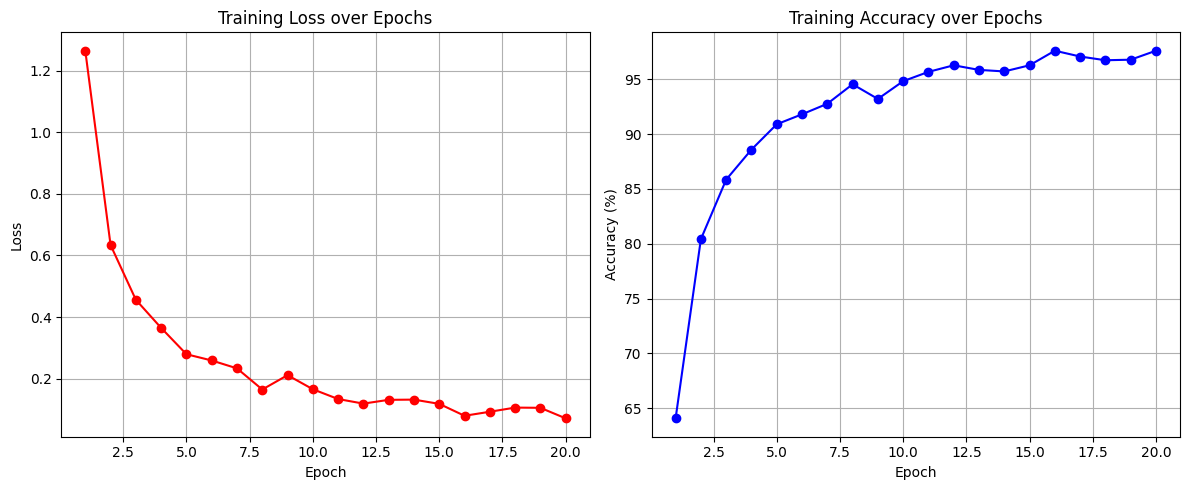

In [ ]:


from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Put the model in evaluation mode
model.eval()

all_labels = []
all_preds = []

# Disable gradient calculation for evaluation
with torch.no_grad():
    for images, labels in train_loader:  # Using train_loader for evaluation on training data
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

# Generate Confusion Matrix
conf_matrix = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(conf_matrix)

# Generate Classification Report
class_names = train_dataset.classes
class_report = classification_report(all_labels, all_preds, target_names=class_names)
print("\nClassification Report:")
class_report

In [23]:
# prompt: generate code to show confusion matrix and classification report. don't restart training

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Put the model in evaluation mode
model.eval()

all_labels = []
all_preds = []

# Disable gradient calculation for evaluation
with torch.no_grad():
    for images, labels in train_loader:  # Using train_loader for evaluation on training data
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

# Generate Confusion Matrix
conf_matrix = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(conf_matrix)

# Generate Classification Report
# Access the original dataset from the Subset and get the class names
class_names = train_dataset.dataset.classes
class_report = classification_report(all_labels, all_preds, target_names=class_names)
print("\nClassification Report:")
print(class_report)

Confusion Matrix:
[[400   1   0 ...   0   0   1]
 [  0 254   0 ...   2   0   0]
 [  0   0 126 ...   0   0   0]
 ...
 [  0   0   0 ... 554   0   1]
 [  0   0   0 ...   0 384   0]
 [  1   0   0 ...   0   0 422]]

Classification Report:
               precision    recall  f1-score   support

     Aloevera       1.00      0.96      0.98       417
         Amla       0.97      0.98      0.98       259
 Amruta_Balli       1.00      0.86      0.93       146
        Arali       1.00      1.00      1.00       146
       Ashoka       0.94      0.98      0.96       336
  Ashwagandha       0.99      0.98      0.98       503
      Avacado       0.97      0.99      0.98       146
       Bamboo       1.00      0.99      1.00       146
       Basale       0.97      0.98      0.98       146
        Betel       1.00      0.79      0.89       151
    Betel_Nut       1.00      0.99      0.99       146
       Brahmi       0.84      1.00      0.91       146
       Castor       0.99      0.99      0.99      

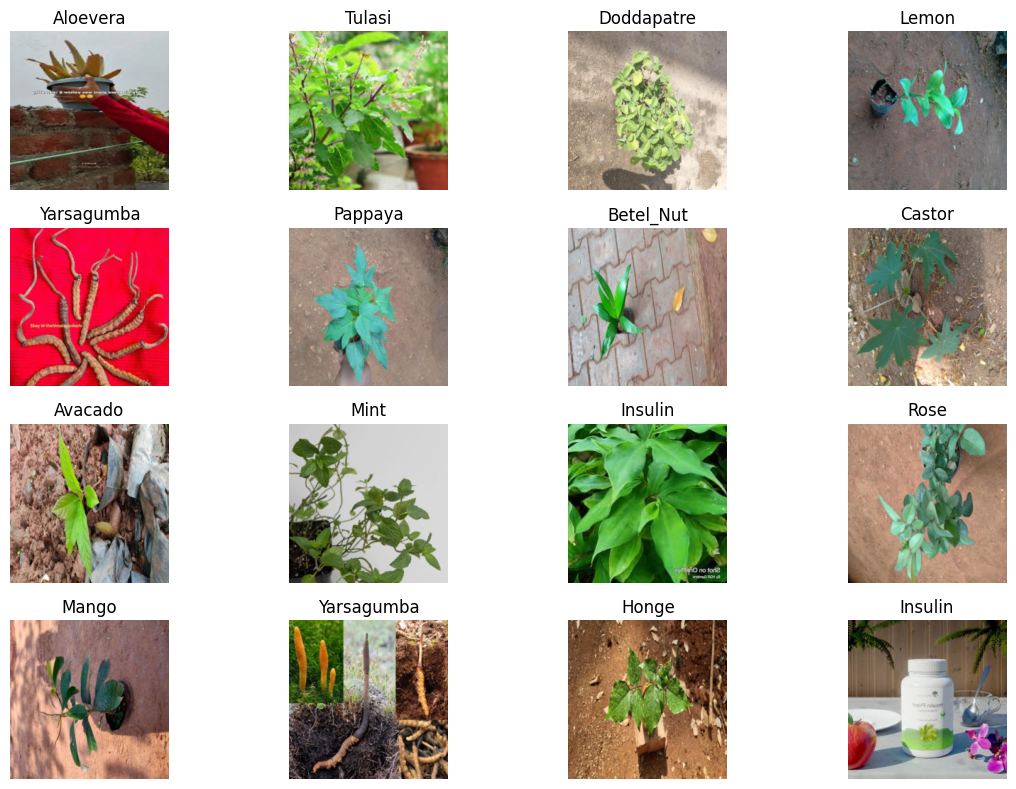

In [25]:
# prompt: show the visualization of labeled data

import matplotlib.pyplot as plt
# Show a batch of images with labels
images, labels = next(iter(train_loader))
# Move images and labels to CPU for visualization if they are on GPU
images, labels = images.cpu(), labels.cpu()

# Unnormalize images if a normalization transform was applied before ToTensor()
# Since the current transform doesn't include normalization, we don't need to unnormalize here.
# If you add transforms.Normalize later, you would add code like this:
# inv_normalize = transforms.Normalize(
#    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
#    std=[1/0.229, 1/0.224, 1/0.225]
# )
# images = inv_normalize(images)

plt.figure(figsize=(12, 8))
for i in range(min(len(images), 16)):  # Display up to 16 images
    plt.subplot(4, 4, i + 1)
    # PyTorch images are (C, H, W), matplotlib expects (H, W, C)
    plt.imshow(images[i].permute(1, 2, 0))
    # Access the original dataset from the Subset and get the class names
    plt.title(train_dataset.dataset.classes[labels[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

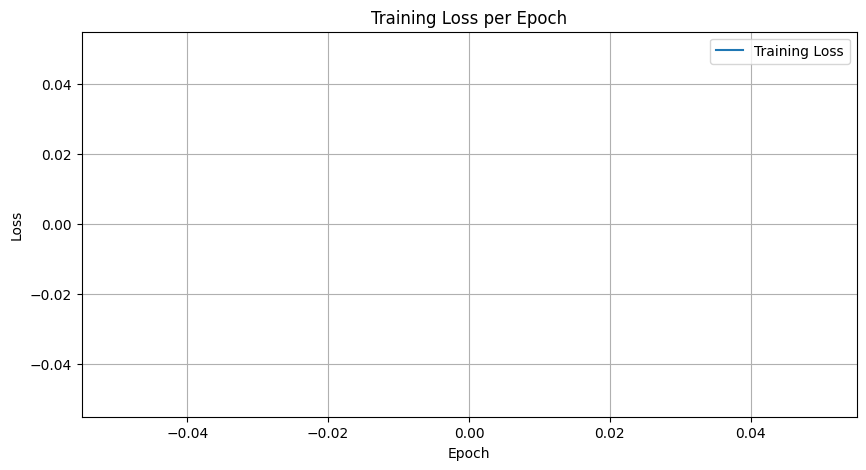

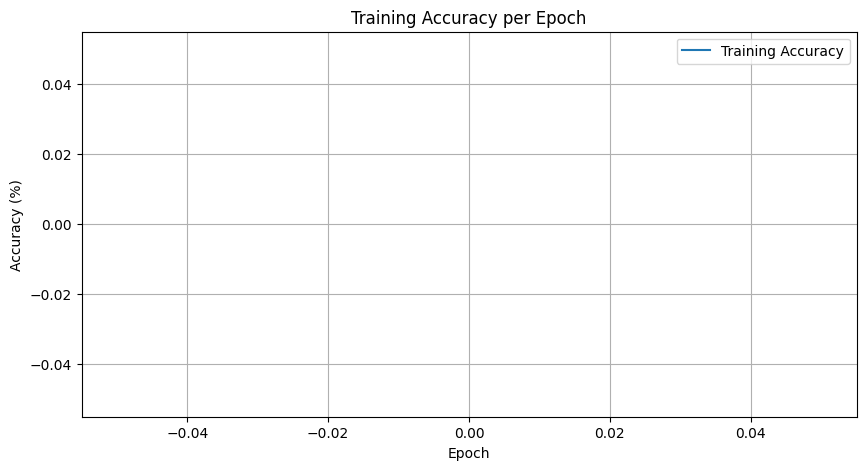

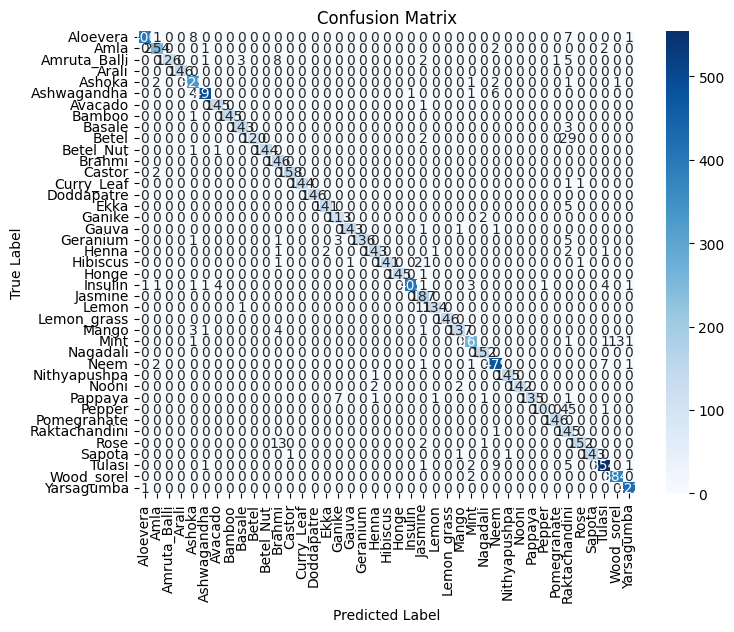

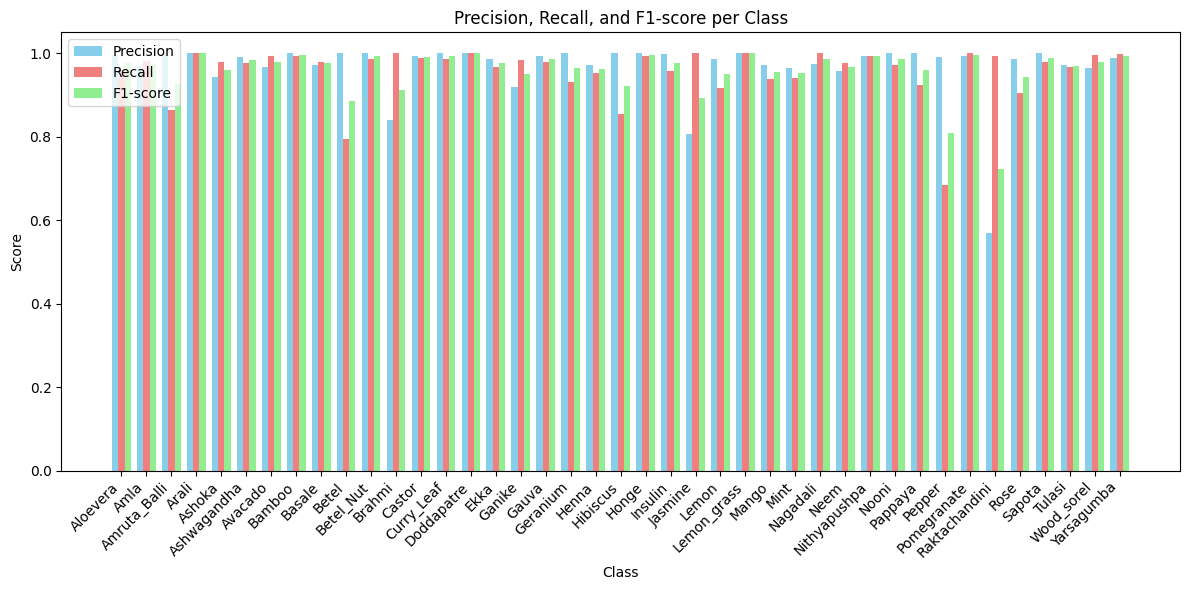

In [29]:
# prompt: model performance analysis in graph don't retrian

import matplotlib.pyplot as plt
import numpy as np

# You need to store the loss and accuracy values during the training loop
# Initialize lists to store loss and accuracy per epoch
epoch_loss = []
epoch_accuracy = []

# The training loop is in a previous cell, but the code to append
# loss and accuracy was commented out in the prompt block.
# Assuming the training loop looks something like this (from the provided context):
# for epoch in range(epochs):
#     running_loss = 0.0
#     correct = 0
#     total = 0
#
#     model.train()
#     for images, labels in train_loader:
#         images, labels = images.to(device), labels.to(device)
#
#         optimizer.zero_grad()
#         outputs = model(images)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()
#
#         running_loss += loss.item()
#         _, predicted = torch.max(outputs.data, 1)
#         total += labels.size(0)
#         correct += (predicted == labels).sum().item()
#
#     acc = 100 * correct / total
#     print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {acc:.2f}%")
#
#     # Add these lines inside the training loop to store the values:
#     # epoch_loss.append(running_loss/len(train_loader))
#     # epoch_accuracy.append(acc)

# Since the training has already been done, we need to ensure
# epoch_loss and epoch_accuracy are populated before plotting.
# If you re-run the training cell with the commented-out lines uncommented,
# these lists will be filled.

# If you cannot re-run the training, and the global variables
# epoch_loss and epoch_accuracy contain the values (which they don't seem to fully based on the error),
# you would use those. However, the error indicates they are not properly populated.

# Assume epoch_loss and epoch_accuracy are now populated from the training loop

# Plotting the training loss
plt.figure(figsize=(10, 5))
# Ensure the range for the x-axis matches the number of recorded epochs
plt.plot(range(1, len(epoch_loss) + 1), epoch_loss, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch')
plt.legend()
plt.grid(True)
plt.show()

# Plotting the training accuracy
plt.figure(figsize=(10, 5))
# Ensure the range for the x-axis matches the number of recorded epochs
plt.plot(range(1, len(epoch_accuracy) + 1), epoch_accuracy, label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy per Epoch')
plt.legend()
plt.grid(True)
plt.show()

# To get the classification report and confusion matrix for the entire dataset
# The evaluation loop you already have calculates this.
# The output from print(conf_matrix) and print(class_report) provides this information.
# If you want to visualize the confusion matrix, you can use seaborn
!pip install seaborn
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# The printed classification report is already a good summary of precision, recall, and F1-score.
# You can parse the classification_report string if you want to visualize specific metrics per class.
# For example, to get precision per class:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_per_class = precision_score(all_labels, all_preds, average=None)
recall_per_class = recall_score(all_labels, all_preds, average=None)
f1_score_per_class = f1_score(all_labels, all_preds, average=None)

plt.figure(figsize=(12, 6))
bar_width = 0.25
index = np.arange(len(class_names))

plt.bar(index, precision_per_class, bar_width, label='Precision', color='skyblue')
plt.bar(index + bar_width, recall_per_class, bar_width, label='Recall', color='lightcoral')
plt.bar(index + 2 * bar_width, f1_score_per_class, bar_width, label='F1-score', color='lightgreen')

plt.xlabel('Class')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1-score per Class')
plt.xticks(index + bar_width, class_names, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()